In this notebook I test the output of MTL (Binary classsification ) utlizing hard gate.

### Environment Setting

In [ ]:
! nvidia-smi

Mon May 19 07:42:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Using GPU: Tesla T4


In [ ]:
!pip install pytorch-lightning
!pip install transformers
!pip install farasapy
!pip install PyArabic
! pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 63.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitli

In [ ]:
# Import Basics
import pandas as pd
import json
import numpy as np
from tqdm.auto import tqdm
import pickle
import re
import os
import pandas as pd
import json
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
# Pytorch
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
#from pytorch_lightning.metrics.functional import accuracy, f1, auroc
#https://torchmetrics.readthedocs.io/en/stable/metrics.html
#https://stackoverflow.com/questions/69139618/torchmetrics-does-not-work-with-pytorchlightning
from torchmetrics.functional import accuracy, f1_score, precision, recall, confusion_matrix
from sklearn.metrics import classification_report, multilabel_confusion_matrix,precision_recall_fscore_support, accuracy_score
import torch.nn.functional as F

In [ ]:
# Visualisation
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
rcParams['figure.figsize'] = 4, 4
tqdm.pandas()

In [ ]:
#OpenAI

from openai import OpenAI
import openai
import pandas as pd
import json
from sklearn.metrics import precision_recall_fscore_support,accuracy_score

import openai
import time

In [ ]:
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


### Read All test Dataset

In [ ]:
import pandas as pd
# ## In this notebook I test the output of MTL (Binary classsification ) utlizing hard gate.


df = pd.read_json("/content/ArMPro_span_test.jsonl", lines=True)

columns_to_delete = ['page_id', 'paragraph_id', 'page_domain', 'page_url', 'page_title', 'page_date']
df = df.drop(columns=columns_to_delete, errors='ignore')

df.head()


,paragraph,labels
0,فيما أشار الدكتور أحمد خليفة، الرئيس التنفيذي ...,[]
1,"وقال ""لديه الموهبة والجودة، الأمر لا يتعلق بتس...","[{'technique': 'Loaded_Language', 'text': 'وال..."
2,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,"[{'technique': 'Flag_Waving', 'text': 'الرعاية..."
3,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,"[{'technique': 'Name_Calling-Labeling', 'text'..."
4,وجاء إعلان السلطات السورية لينفي معلومات نشرها...,[]


### Read the output (only propaganda) form MTL_Sentiment_UW

In [ ]:
import pandas as pd

# Load Excel file from specific sheet
df_MTL = pd.read_excel("/content/MTL_Sentiment_UW_PredictedLabels.xlsx", sheet_name="Binary+Span+Predected(onlyProp)")

# Drop unwanted columns
df_MTL = df_MTL.drop(columns=['Unnamed: 0','label', 'predicted labels','paragraph_id'], errors='ignore')

# Preview cleaned DataFrame
df_MTL.tail()

,paragraph,labels
790,“في الوقت الذي تعقد الاجتماعات المستمرة لكتل ا...,"[{'technique': 'Loaded_Language', 'text': 'مخا..."
791,أثارت مأساة الروهينغا في إقليم أراكان بميانمار...,"[{'technique': 'Loaded_Language', 'text': 'أثا..."
792,قال مدير عام منظمة الصحة العالمية، تيدروس غيبر...,"[{'technique': 'Loaded_Language', 'text': 'تفش..."
793,ومنعت جبهة تحرير شعب تيغراي يوم الجمعة الماضي ...,[]
794,تتميز هونغ كونغ بالعديد من المعالم السياحية وا...,[]


In [ ]:
# Drop rows with NaN values in any column
df_MTL = df_MTL.dropna()


In [ ]:
# convert stringified lists to real Python objects
import ast
df_MTL['labels'] = df_MTL['labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


In [ ]:
df_MTL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   paragraph  795 non-null    object
 1   labels     795 non-null    object
dtypes: object(2)
memory usage: 12.6+ KB


In [ ]:
# Reload labels into list after fix
true_labels = df_MTL['labels'].tolist()

# a. Count how many true_labels are still empty lists
empty_count = sum(1 for label in true_labels if label == [])
print(f"Empty Gold Spans (after parsing): {empty_count} / {len(true_labels)}")

# b. Print first 5 examples of parsed gold spans
print("\nSample Parsed Gold Spans:")
for i, label in enumerate(true_labels[:5]):
    print(f"{i}: {label}")

Empty Gold Spans (after parsing): 124 / 795

Sample Parsed Gold Spans:
0: [{'technique': 'Flag_Waving', 'text': 'الرعاية الصحية والنفسية للأطفال هي من بين الاولويات التي تسعى اليها الجزائر', 'start': 0, 'end': 75}]
1: [{'technique': 'Name_Calling-Labeling', 'text': 'دول الحصار', 'start': 34, 'end': 44}, {'technique': 'Loaded_Language', 'text': 'للأزمة', 'start': 60, 'end': 66}]
2: [{'technique': 'Exaggeration-Minimisation', 'text': ' مستقبل أكثر نجاحًا', 'start': 138, 'end': 157}, {'technique': 'Loaded_Language', 'text': 'أكثر نجاحًا', 'start': 146, 'end': 157}, {'technique': 'Exaggeration-Minimisation', 'text': 'مستقبل أكثر نجاحًا', 'start': 139, 'end': 157}, {'technique': 'Repetition', 'text': 'الاحتفال', 'start': 14, 'end': 22}, {'technique': 'Repetition', 'text': 'ويحتفل', 'start': 158, 'end': 164}, {'technique': 'Repetition', 'text': 'للاحتفال', 'start': 224, 'end': 232}]
3: []
4: [{'technique': 'Loaded_Language', 'text': 'أثار', 'start': 148, 'end': 152}]


## Prepear the Data
1. Tokenize each paragraph into words.

2. Map spans (start–end) into token positions.

3. Tag each token with encoding schema:

*   B-<LABEL> for beginning of span
*   I-<LABEL> for inside
*   O otherwise







In [ ]:
def arabic_tokenize_with_offsets(text):
    """
    Arabic-safe tokenizer with proper word matching including tanween and diacritics.
    """
    # Arabic letters + diacritics + digits + Latin letters
    word = r'[\u0621-\u0652a-zA-Z0-9]+'
    punct = r'[،؛:,.!?()\[\]{}"\'«»“”…]+'
    pattern = re.compile(f'{word}|{punct}')

    tokens = []
    for match in pattern.finditer(text):
        token = match.group()
        start = match.start()
        end = match.end()
        tokens.append((token, start, end))
    return tokens


In [ ]:
def convert_to_multilabel_bio_fixed(df):
    all_bio = []

    for _, row in df.iterrows():
        text = row["paragraph"]
        raw_labels = row.get("labels", [])

        parsed_labels = []
        if isinstance(raw_labels, str):
            try:
                if '},{' in raw_labels:
                    raw_labels = "[" + raw_labels.replace("},", "},") + "]"
                parsed_labels = json.loads(raw_labels)
            except:
                parsed_labels = []
        elif isinstance(raw_labels, list):
            parsed_labels = raw_labels

        token_offsets = arabic_tokenize_with_offsets(text)
        tags_per_token = [set() for _ in token_offsets]

        for label in parsed_labels:
            label_start = label["start"]
            label_end = label["end"]
            label_tag = label["technique"].replace(" ", "_")
            first = True
            for i, (_, tok_start, tok_end) in enumerate(token_offsets):
                if tok_end > label_start and tok_start < label_end:
                    prefix = 'B-' if first else 'I-'
                    tags_per_token[i].add(f'{prefix}{label_tag}')
                    first = False

        tokens = [tok for tok, _, _ in token_offsets]
        final_tags = ["|".join(sorted(tags)) if tags else "O" for tags in tags_per_token]
        all_bio.append(list(zip(tokens, final_tags)))

    return all_bio


In [ ]:
# --- Step 4:Generate BIO format
bio_output = convert_to_multilabel_bio_fixed(df)



TypeError: expected string or bytes-like object, got 'float'

In [ ]:
df.head(20)

,paragraph,labels
0,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,"[{'technique': 'Flag_Waving', 'text': 'الرعاية..."
1,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,"[{'technique': 'Name_Calling-Labeling', 'text'..."
2,لا زالت أصداء الاحتفال بيوم المعلم العالمي متو...,"[{'technique': 'Exaggeration-Minimisation', 't..."
3,واعتبرت جبهة بوليساريو أن العملية المغربية أنه...,[]
4,ويعقد اللقاء بين رئيسي الدولتين في أجواء أفضل ...,"[{'technique': 'Loaded_Language', 'text': 'أثا..."
5,"وأوضح: ""في بعض البلدان، مثل سوريا واليمن وليبي...","[{'technique': 'Loaded_Language', 'text': 'للن..."
6,كان استقبال العقيد معمّر القذافي وزيرة الخارجي...,"[{'technique': 'Loaded_Language', 'text': 'تار..."
7,اليوم لا تزال الجزائر تنظر إلى هذه المجاهدة ال...,"[{'technique': 'Name_Calling-Labeling', 'text'..."
8,قالت المنظمة الكندية غير الحكومية ICASA إن ثمة...,[]
9,رافق معالي رئيس مجلس الوزراء ووزير الداخلية، س...,"[{'technique': 'Loaded_Language', 'text': 'سعا..."


### Convert BIO Tags Back to Spans

**convert model predictions (BIO tags) back into start, end, and technique format for evaluation**

* **BIO-tagged tokens look like the following:**

[
  ("أكثر", "B-Exaggeration-Minimisation|B-Loaded_Language"),
  ("نجاحًا", "I-Exaggeration-Minimisation|I-Loaded_Language"),
  (".", "O"),
  ("ويحتفل", "B-Repetition")
]

* **Produce output look like the following:**


[
  {"technique": "Exaggeration-Minimisation", "text": "أكثر نجاحًا", "start": 5, "end": 17},
  {"technique": "Loaded_Language", "text": "أكثر نجاحًا", "start": 5, "end": 17},
  {"technique": "Repetition", "text": "ويحتفل", "start": 20, "end": 27}
]


In [ ]:
def bio_to_spans(paragraph, tokens_with_tags, token_offsets):
    spans = []
    active_spans = {}

    for i, (token, tag_str) in enumerate(tokens_with_tags):
        tok_start, tok_end = token_offsets[i][1], token_offsets[i][2]
        tags = tag_str.split("|") if tag_str != "O" else []
        current_labels = set()

        for tag in tags:
            prefix, label = tag.split("-", 1)
            current_labels.add(label)

            if prefix == "B":
                if label in active_spans:
                    prev = active_spans[label]
                    spans.append({
                        "technique": label,
                        "text": paragraph[prev["start"]:prev["end"]],
                        "start": prev["start"],
                        "end": prev["end"]
                    })
                active_spans[label] = {"start": tok_start, "end": tok_end}
            elif prefix == "I" and label in active_spans:
                active_spans[label]["end"] = tok_end

        to_close = []
        for label in active_spans:
            if label not in current_labels:
                prev = active_spans[label]
                spans.append({
                    "technique": label,
                    "text": paragraph[prev["start"]:prev["end"]],
                    "start": prev["start"],
                    "end": prev["end"]
                })
                to_close.append(label)
        for label in to_close:
            del active_spans[label]

    for label, span in active_spans.items():
        spans.append({
            "technique": label,
            "text": paragraph[span["start"]:span["end"]],
            "start": span["start"],
            "end": span["end"]
        })

    return spans





In [ ]:
df.head(1)

,paragraph,labels
0,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,"[{'technique': 'Flag_Waving', 'text': 'الرعاية..."


# Open AI

In [ ]:


client = openai.OpenAI(api_key='AsGe4XXXXXXXXXMA')

#Lubna's Key
#client = openai.OpenAI(api_key='sk-GVnj_icwv8j0yewtpkOHXXXXXXXXlK25nTDMfi-Fv2dgPdyiYsA')


#Lubna's model
#model_id='ft:gpt-4o-mini-2024-07-18:personal:binarypropaganda:A4aUIOJv'
#model_id='gpt-4-0613'
#model_id='gpt-4-1106-preview'
model_id='gpt-4o'


In [ ]:
# Assuming your Excel file has two columns: 'text' and 'true_label'
# texts = df['paragraph'][1315:1325].tolist()
# true_labels = df['labels'][1315:1325].tolist()

texts = df_MTL['paragraph'].tolist()
true_labels = df_MTL['labels'].tolist()

In [ ]:
len(texts)

795

In [ ]:
import json
from collections import defaultdict
from sklearn.metrics import precision_recall_fscore_support

#"no_technique",
# -------------------------------
# Classify text using OpenAI GPT-4
# -------------------------------
def classify_text(text):
    response = client.chat.completions.create(
        model=model_id,
        messages=[
            {
                "role": "system",
                "content": """
Label the text by the following propaganda techniques:
[
    "Appeal_to_Authority", "Appeal_to_Fear-Prejudice", "Appeal_to_Hypocrisy",
    "Appeal_to_Popularity", "Appeal_to_Time", "Appeal_to_Values",
    "Causal_Oversimplification", "Consequential_Oversimplification",
    "Conversation_Killer", "Doubt", "Exaggeration-Minimisation",
    "False_Dilemma-No_Choice", "Flag_Waving", "Guilt_by_Association",
    "Loaded_Language", "Name_Calling-Labeling",
    "Obfuscation-Vagueness-Confusion", "Questioning_the_Reputation",
    "Red_Herring", "Repetition", "Slogans", "Straw_Man", "Whataboutism"
]

Answer exactly and only by returning a list of the matching labels from the aforementioned techniques and specify the start position and end position of the text span matching each technique. Use this template {"technique": , "text": , "start": , "end": }
"""
            },
            {"role": "user", "content": text}
        ],
        temperature=0,
        max_tokens=512
    )


    try:
        result = response.choices[0].message.content.strip()

        # Remove Markdown-style code block (```json\n...\n```)
        result = re.sub(r"^```json\n?|```$", "", result).strip()

        spans = json.loads(result)

        if isinstance(spans, dict):
            spans = [spans]

        spans = [
            s for s in spans
            if isinstance(s, dict) and 'technique' in s and 'start' in s and 'end' in s
        ]

    except Exception as e:
        print("Failed to parse GPT-4 response:", e)
        print("Raw output:", response.choices[0].message.content)
        spans = []

    return spans  # Always returns list[dict]


In [ ]:
# -------------------------------
# Evaluation (partial overlap F1)
# -------------------------------
def span_overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start))

def compute_partial_match_metrics(predicted, gold):
    pred_by_label = defaultdict(list)
    gold_by_label = defaultdict(list)

    for s in predicted:
        pred_by_label[s['technique']].append(s)

    for g in gold:
        gold_by_label[g['technique']].append(g)

    all_labels = sorted(set(pred_by_label) | set(gold_by_label))



    macro_f1s = []
    total_tp = total_fp = total_fn = 0

    for label in all_labels:
        preds = pred_by_label[label]
        gts = gold_by_label[label]

        # precision
        P_sum = 0.0
        for s in preds:
            best = 0.0
            for t in gts:
                overlap = span_overlap(s['start'], s['end'], t['start'], t['end'])
                best = max(best, overlap / max(1, (s['end'] - s['start'])))
            P_sum += best
        P = P_sum / len(preds) if preds else 0

        # recall
        R_sum = 0.0
        for t in gts:
            best = 0.0
            for s in preds:
                overlap = span_overlap(s['start'], s['end'], t['start'], t['end'])
                best = max(best, overlap / max(1, (t['end'] - t['start'])))
            R_sum += best
        R = R_sum / len(gts) if gts else 0

        F1 = 2 * P * R / (P + R) if (P + R) else 0.0
        macro_f1s.append(F1)

        total_tp += P_sum
        total_fp += len(preds) - P_sum
        total_fn += len(gts) - R_sum





    micro_p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
    micro_r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
    micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) else 0

    total_predicted= sum(len(v) for v in pred_by_label.values()) #total predicted spans (regardless of label such as 2 loaded language and 1 name calling)
    total_gold= sum(len(v) for v in gold_by_label.values())

    if total_gold == 0 and total_predicted == 0:
      return {
          "micro_precision": 1.0,
          "micro_recall": 1.0,
          "micro_f1": 1.0,
          "macro_f1": 1.0,
          "total_predicted": 0,
          "total_gold": 0,
          "unique_labels": []
      }



    return {
        "micro_precision": round(micro_p, 4),
        "micro_recall": round(micro_r, 4),
        "micro_f1": round(micro_f1, 4),
        "macro_f1": round(sum(macro_f1s) / len(macro_f1s), 4) if macro_f1s else 0.0,
        "total_predicted":  total_predicted,#total predicted spans (regardless of label such as 2 loaded language and 1 name calling)
        "total_gold": total_gold,
        "unique_labels": all_labels
    }


In [ ]:
def fix_gpt_spans(predicted_spans, paragraph):
    fixed = []
    for span in predicted_spans:
        text = span['text']
        start = paragraph.find(text)
        if start != -1:
            end = start + len(text)
            span['start'] = start
            span['end'] = end
        fixed.append(span)
    return fixed

### Classification to all examples with post-prediction heuristic

In [ ]:
# Step 1: Collect predicted spans for each paragraph
all_predicted_spans = [classify_text(text) for text in texts]

# Step 2: Apply post-prediction fix for each prediction using corresponding paragraph
all_fixed_spans = [fix_gpt_spans(preds, para) for preds, para in zip(all_predicted_spans, texts)]

# Step 3: Evaluate all predictions against true labels
all_scores = []
for fixed_pred, gold in zip(all_fixed_spans, true_labels):
    if isinstance(gold, str):
        try:
            gold = json.loads(gold)
        except:
            gold = []
    all_scores.append(compute_partial_match_metrics(fixed_pred, gold))

# Step 4: Aggregate results
micro_f1s = [s['micro_f1'] for s in all_scores]
macro_f1s = [s['macro_f1'] for s in all_scores]

average_micro_f1 = round(sum(micro_f1s) / len(micro_f1s), 4)
average_macro_f1 = round(sum(macro_f1s) / len(macro_f1s), 4)

print("Evaluation over full dataset:")
print(f"Average Micro-F1: {average_micro_f1}")
print(f"Average Macro-F1: {average_macro_f1}")



# Step 5: Create DataFrame
rows = []
for i in range(len(texts)):
    gold = true_labels[i]
    if isinstance(gold, str):
        try:
            gold = json.loads(gold)
        except:
            gold = []
    rows.append({
        "Text": texts[i],
        "Gold span": gold,
        "Predicted spans for post-predecation heurstic:": all_fixed_spans[i]
    })

df = pd.DataFrame(rows)

# Step 6: Add average scores to first row
df['Macro-F1'] = [""] * len(df)
df['Micro-F1'] = [""] * len(df)
df.loc[0, 'Macro-F1'] = average_macro_f1
df.loc[0, 'Micro-F1'] = average_micro_f1

# Step 7: Save to Excel
df.to_excel("Openai_model_id_gpt_4o_MTL_post_prediction_heuristic.xlsx", index=False)




# Move the additional files to Drive
shutil.move("/content/Openai_model_id_gpt_4o_MTL_post_prediction_heuristic.xlsx", "/content/drive/My Drive//Colab Notebooks/MTL Results/Openai_model_id_gpt_4o_MTL_post_prediction_heuristic.xlsx")

print("Predictions and confusion matrix saved and moved successfully.")

Evaluation over full dataset:
Average Micro-F1: 0.1748
Average Macro-F1: 0.1639
Predictions and confusion matrix saved and moved successfully.


### Classification to all examples without post-prediction heuristic

In [ ]:
# Step 1: Collect predicted spans for each paragraph (without fixing)
all_predicted_spans = [classify_text(text) for text in texts]


# Step 2: Evaluate all predictions against true labels
all_scores = []
for pred, gold in zip(all_predicted_spans, true_labels):
    if isinstance(gold, str):
        try:
            gold = json.loads(gold)
        except:
            gold = []
    all_scores.append(compute_partial_match_metrics(pred, gold))

# Step 4: Aggregate F1 scores
micro_f1s = [s['micro_f1'] for s in all_scores]
macro_f1s = [s['macro_f1'] for s in all_scores]
average_micro_f1 = round(sum(micro_f1s) / len(micro_f1s), 4)
average_macro_f1 = round(sum(macro_f1s) / len(macro_f1s), 4)

print("Evaluation over full dataset (no heuristic):")
print(f"Average Micro-F1: {average_micro_f1}")
print(f"Average Macro-F1: {average_macro_f1}")

# Step 5: Create DataFrame
rows = []
for i in range(len(texts)):
    gold = true_labels[i]
    if isinstance(gold, str):
        try:
            gold = json.loads(gold)
        except:
            gold = []
    rows.append({
        "Text": texts[i],
        "Gold span": gold,
        "Predicted spans (raw)": all_predicted_spans[i]
    })

df = pd.DataFrame(rows)

# Step 6: Add average scores to first row
df['Macro-F1'] = [""] * len(df)
df['Micro-F1'] = [""] * len(df)
df.loc[0, 'Macro-F1'] = average_macro_f1
df.loc[0, 'Micro-F1'] = average_micro_f1

# Step 7: Save to Excel
df.to_excel("Openai_model_id_gpt_4o_MTL_without_post_prediction_heuristic.xlsx", index=False)


# Move the additional files to Drive
shutil.move("/content/Openai_model_id_gpt_4o_MTL_without_post_prediction_heuristic.xlsx", "/content/drive/My Drive//Colab Notebooks/MTL Results/Openai_model_id_gpt_4o_MTL_without_post_prediction_heuristic.xlsx")

print("Predictions and confusion matrix saved and moved successfully.")

Evaluation over full dataset (no heuristic):
Average Micro-F1: 0.1555
Average Macro-F1: 0.1492
Predictions and confusion matrix saved and moved successfully.


### Classification to one example

In [ ]:
paragraph = df.iloc[0]['paragraph']
gold_spans = df.iloc[0]['labels']

print(paragraph)
print(gold_spans)

فيما أشار الدكتور أحمد خليفة، الرئيس التنفيذي لمجموعة “سي إف سي” الإماراتية، إلى أنه من المخطط خلال شهر فبراير المقبل البدء في أعمال المقاولات بمشروع الشركة الخاص بإنشاء مجمع صناعي لإنتاج الأعلاف والكيماويات والمخصبات بمحافظة قنا.
[]


In [ ]:
# With case of implmentaion post-prediction heuristic


paragraph = df.iloc[15]['paragraph']
gold_spans = df.iloc[15]['labels']



# Step 1: Get predicted spans from GPT
predicted_spans = classify_text(paragraph)

# Step 2: Fix offsets based on first match in paragraph
predicted_spans = fix_gpt_spans(predicted_spans, paragraph)

# Step 3: Evaluate
scores = compute_partial_match_metrics(predicted_spans, gold_spans)

print(scores)


{'micro_precision': 0.25, 'micro_recall': 0.099, 'micro_f1': 0.1418, 'macro_f1': 0.0659, 'total_predicted': 4, 'total_gold': 10, 'unique_labels': ['Appeal_to_Values', 'Exaggeration-Minimisation', 'Flag_Waving', 'Loaded_Language', 'Name_Calling-Labeling', 'Obfuscation-Vagueness-Confusion', 'Questioning_the_Reputation']}


In [ ]:
print("Gold span:", gold_spans)
print("Predicted spans for post-predecation heurstic:", predicted_spans)

Gold span: [{'technique': 'Name_Calling-Labeling', 'text': 'المجاهدة الكبيرة', 'start': 35, 'end': 51}, {'technique': 'Loaded_Language', 'text': 'وطنية كبيرة', 'start': 138, 'end': 149}, {'technique': 'Obfuscation-Vagueness-Confusion', 'text': 'وهي تمر اليوم بمخاض عسير', 'start': 192, 'end': 216}, {'technique': 'Name_Calling-Labeling', 'text': 'نظام', 'start': 327, 'end': 331}, {'technique': 'Name_Calling-Labeling', 'text': 'المجاهد', 'start': 361, 'end': 368}, {'technique': 'Flag_Waving', 'text': 'لم تتوقف مبادرات الحوار عن الإشارة إلى اسمها كشخصية وطنية كبيرة من شأنها قيادة الحوار وتقديم حلول للجزائر', 'start': 86, 'end': 191}, {'technique': 'Questioning_the_Reputation', 'text': 'ترفض الحوار مع نظام تقول إنه سجن أخاها في النضال المجاهد لخضر بورقعة', 'start': 312, 'end': 380}, {'technique': 'Loaded_Language', 'text': 'النضال', 'start': 354, 'end': 360}, {'technique': 'Loaded_Language', 'text': 'بمخاض عسير', 'start': 206, 'end': 216}, {'technique': 'Exaggeration-Minimisation', 'text': 

In [ ]:
# Without case of  implment post-prediction heuristic

paragraph = df.iloc[15]['paragraph']
gold_spans = df.iloc[15]['labels']

# If labels are stored as strings
if isinstance(gold_spans, str):
    gold_spans = json.loads(gold_spans)

# Classify with GPT
predicted_spans = classify_text(paragraph)

# Evaluate
scores = compute_partial_match_metrics(predicted_spans, gold_spans)
print(scores)


{'micro_precision': 0.125, 'micro_recall': 0.0498, 'micro_f1': 0.0712, 'macro_f1': 0.0332, 'total_predicted': 4, 'total_gold': 10, 'unique_labels': ['Appeal_to_Values', 'Exaggeration-Minimisation', 'Flag_Waving', 'Loaded_Language', 'Name_Calling-Labeling', 'Obfuscation-Vagueness-Confusion', 'Questioning_the_Reputation']}


In [ ]:
print("Gold span:", gold_spans)
print("Predicted spans:", predicted_spans)

Gold span: [{'technique': 'Name_Calling-Labeling', 'text': 'المجاهدة الكبيرة', 'start': 35, 'end': 51}, {'technique': 'Loaded_Language', 'text': 'وطنية كبيرة', 'start': 138, 'end': 149}, {'technique': 'Obfuscation-Vagueness-Confusion', 'text': 'وهي تمر اليوم بمخاض عسير', 'start': 192, 'end': 216}, {'technique': 'Name_Calling-Labeling', 'text': 'نظام', 'start': 327, 'end': 331}, {'technique': 'Name_Calling-Labeling', 'text': 'المجاهد', 'start': 361, 'end': 368}, {'technique': 'Flag_Waving', 'text': 'لم تتوقف مبادرات الحوار عن الإشارة إلى اسمها كشخصية وطنية كبيرة من شأنها قيادة الحوار وتقديم حلول للجزائر', 'start': 86, 'end': 191}, {'technique': 'Questioning_the_Reputation', 'text': 'ترفض الحوار مع نظام تقول إنه سجن أخاها في النضال المجاهد لخضر بورقعة', 'start': 312, 'end': 380}, {'technique': 'Loaded_Language', 'text': 'النضال', 'start': 354, 'end': 360}, {'technique': 'Loaded_Language', 'text': 'بمخاض عسير', 'start': 206, 'end': 216}, {'technique': 'Exaggeration-Minimisation', 'text': 

In [ ]:
df.head(19)

,paragraph,labels
0,فيما أشار الدكتور أحمد خليفة، الرئيس التنفيذي ...,[]
1,"وقال ""لديه الموهبة والجودة، الأمر لا يتعلق بتس...","[{'technique': 'Loaded_Language', 'text': 'وال..."
2,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,"[{'technique': 'Flag_Waving', 'text': 'الرعاية..."
3,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,"[{'technique': 'Name_Calling-Labeling', 'text'..."
4,وجاء إعلان السلطات السورية لينفي معلومات نشرها...,[]
5,لا زالت أصداء الاحتفال بيوم المعلم العالمي متو...,"[{'technique': 'Exaggeration-Minimisation', 't..."
6,وأضاف أنه يعتقد أنه سيتم حقن معظم الجرعات في غ...,[]
7,وحصلت عشرة سعوديات على رخص قيادة في الخامس من ...,[]
8,ويحتاج الفلسطينيون إلى إذن خاص من إسرائيل يقدم...,[]
9,واعتبرت جبهة بوليساريو أن العملية المغربية أنه...,[]


In [ ]:
for pred in predicted_spans:
    print("Pred:", pred, "| text →", paragraph[pred['start']:pred['end']])
for gold in gold_spans:
    print("Gold:", gold, "| text →", paragraph[gold['start']:gold['end']])

Gold: {'technique': 'Flag_Waving', 'text': 'الرعاية الصحية والنفسية للأطفال هي من بين الاولويات التي تسعى اليها الجزائر', 'start': 0, 'end': 75} | text → الرعاية الصحية والنفسية للأطفال هي من بين الاولويات التي تسعى اليها الجزائر


In [ ]:
# Make a test request to check the headers
response = client.chat.completions.with_raw_response.create(
    model=model_id,
    messages=[{"role": "system", "content": "Check rate limit headers"}],

)

print('How many requests you have left in the current time window, Out of 200 how many remaining?',response.headers.get('x-ratelimit-remaining-requests'))
print('The maximum number of requests youre allowed to make in a given time period',response.headers.get('x-rateLimit-limit-requests'))
print('The time at which the rate limit will reset',response.headers.get('x-rateLimit-reset-requests'))

# get the object that `chat.completions.create()` would have returned
completion = response.parse()
print(completion)


How many requests you have left in the current time window, Out of 200 how many remaining? 4999
The maximum number of requests youre allowed to make in a given time period 5000
The time at which the rate limit will reset 12ms
ChatCompletion(id='chatcmpl-BY866bmblSXS85hWzjhNnTAMsYr6C', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Rate limit headers are HTTP headers that provide information about the rate-limiting policies a service uses. These are primarily consumed by APIs but can be identified using tools like `curl` or even your web browser developer tools. Here's a list of common rate limit headers and what they represent:\n\n1. `X-RateLimit-Limit`: The maximum number of requests you can make in a given time frame.\n2. `X-RateLimit-Remaining`: The number of requests you can still make in the current time frame.\n3. `X-RateLimit-Reset`: The time when the rate limit will be reset (usually presented in Unix-time).\n\nLet's say you

# Analysis the Results

In [ ]:
import pandas as pd

# Load Excel file from specific sheet
df= pd.read_excel("/content/Openai_FineGrained_model_id_gpt_4o.xlsx", sheet_name="MTL_with_PostPredecation_Heuris")

# Drop unwanted columns
df= df.drop(columns=['Macro-F1','Micro-F1', 'Amount of Data'], errors='ignore')

# Preview cleaned DataFrame
df.head()

,Text,Gold span,Predicted spans for post-predecation heurstic:
0,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,"[{'technique': 'Flag_Waving', 'text': 'الرعاية...",[]
1,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,"[{'technique': 'Name_Calling-Labeling', 'text'...",[]
2,لا زالت أصداء الاحتفال بيوم المعلم العالمي متو...,"[{'technique': 'Exaggeration-Minimisation', 't...",[]
3,واعتبرت جبهة بوليساريو أن العملية المغربية أنه...,[],[]
4,ويعقد اللقاء بين رئيسي الدولتين في أجواء أفضل ...,"[{'technique': 'Loaded_Language', 'text': 'أثا...",[]


In [ ]:
# Ensure both columns are strings for comparison
df['Gold span'] = df['Gold span'].astype(str)
df['Predicted spans for post-predecation heurstic:'] = df['Predicted spans for post-predecation heurstic:'].astype(str)

# Total examples
total_examples = len(df)

# Individual empty counts
num_gold_empty = (df['Gold span'] == '[]').sum()
num_pred_empty = (df['Predicted spans for post-predecation heurstic:'] == '[]').sum()

# Both empty
both_empty = (
    (df['Gold span'] == '[]') &
    (df['Predicted spans for post-predecation heurstic:'] == '[]')
).sum()

# False positives: gold is empty but predicted is not
false_positives = (
    (df['Gold span'] == '[]') &
    (df['Predicted spans for post-predecation heurstic:'] != '[]')
).sum()

# Print results
print(f"Total examples: {total_examples}")
print(f"Empty Gold span (Non-Propagandistic): {num_gold_empty} / {total_examples}")
print(f"Empty Predicted spans (Non-Propagandistic): {num_pred_empty} / {total_examples}")
print(f"Both gold and predicted spans are empty (Non-Propagandistic): {both_empty} / {total_examples}")
print(f"False positives (gold = [](Non-Propagandistic), predicted ≠ [](Propagandistic)): {false_positives} / {total_examples}")

Total examples: 795
Empty Gold span (Non-Propagandistic): 124 / 795
Empty Predicted spans (Non-Propagandistic): 547 / 795
Both gold and predicted spans are empty (Non-Propagandistic): 106 / 795
False positives (gold = [](Non-Propagandistic), predicted ≠ [](Propagandistic)): 18 / 795


# Draft

In [ ]:
import pandas as pd

# Load Excel file from specific sheet
df = pd.read_excel("/content/MTL_Sentiment_UW_PredictedLabels.xlsx", sheet_name="Binary+Span+Predected(onlyProp)")

# Drop unwanted columns
df = df.drop(columns=['Unnamed: 0', 'paragraph_id'], errors='ignore')

# Preview cleaned DataFrame
df.head()


,paragraph,label,labels,predicted labels
0,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,1,"[{'technique': 'Flag_Waving', 'text': 'الرعاية...",1
1,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,1,"[{'technique': 'Name_Calling-Labeling', 'text'...",1
2,لا زالت أصداء الاحتفال بيوم المعلم العالمي متو...,1,"[{'technique': 'Exaggeration-Minimisation', 't...",1
3,واعتبرت جبهة بوليساريو أن العملية المغربية أنه...,0,[],1
4,ويعقد اللقاء بين رئيسي الدولتين في أجواء أفضل ...,1,"[{'technique': 'Loaded_Language', 'text': 'أثا...",1


In [ ]:
# prompt: predicted labels
# show values count

from collections import defaultdict

# Assuming 'df' is your DataFrame and 'predicted_labels' is the column name
predicted_label_counts = df['predicted labels'].value_counts()
predicted_label_counts


,count
predicted labels,
1,795


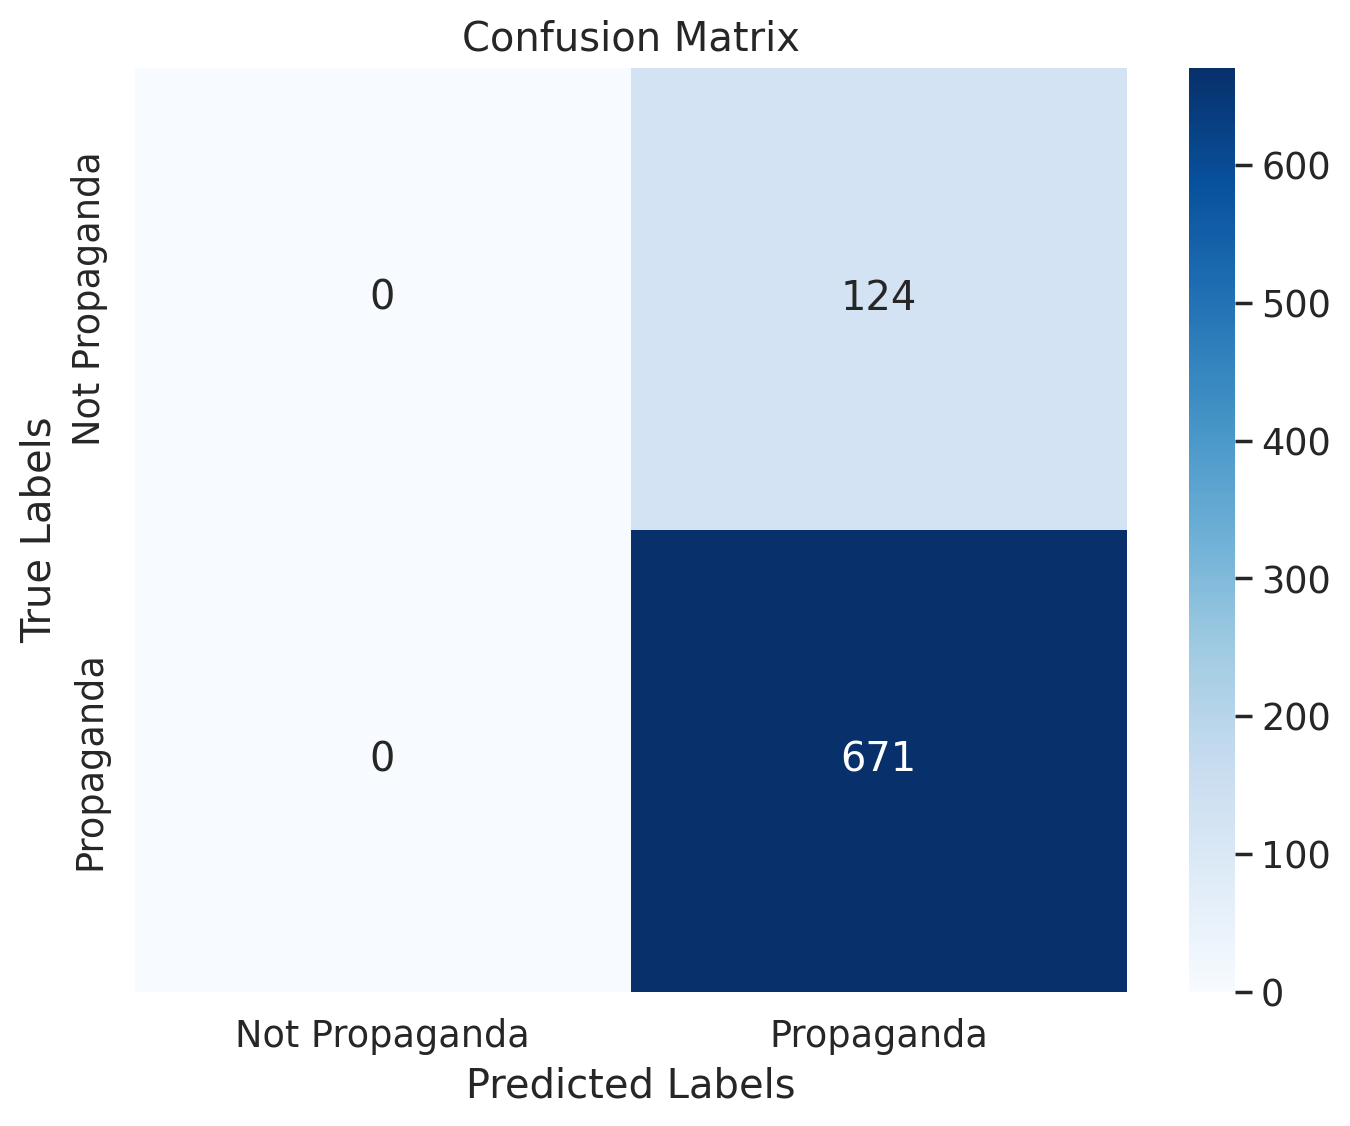

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming 'df' is your DataFrame and contains columns 'predicted labels' and 'label'
#  and that 'predicted labels' and 'label' columns contain 0 and 1

# Create the confusion matrix
cm = confusion_matrix(df['label'], df['predicted labels'])

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Propaganda', 'Propaganda'],
            yticklabels=['Not Propaganda', 'Propaganda'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# prompt: count how many raw predicted labels and label =1 , and how many raw predicted labels=1 and label=0

from collections import defaultdict

# Assuming 'df' is your DataFrame and contains columns 'predicted labels' and 'label'
# and that 'predicted labels' and 'label' columns contain 0 and 1

# Count how many raw predicted labels are 1 and the true label is 1
count_pred1_label1 = len(df[(df['predicted labels'] == 1) & (df['label'] == 1)])

# Count how many raw predicted labels are 1 and the true label is 0
count_pred1_label0 = len(df[(df['predicted labels'] == 1) & (df['label'] == 0)])

print(f"Number of raw predicted labels = 1 and label = 1: {count_pred1_label1}")
print(f"Number of raw predicted labels = 1 and label = 0: {count_pred1_label0}")


Number of raw predicted labels = 1 and label = 1: 671
Number of raw predicted labels = 1 and label = 0: 124


In [ ]:
# Fix: detect 'labels' as string if it's not parsed into Python lists
false_positives = df[
    (df['predicted labels'] == 1) &
    (df['labels'].apply(lambda x: x == [] or x == "[]"))
]

print(f"False positives (predicted=1, labels=[]): {len(false_positives)}")


False positives (predicted=1, labels=[]): 124
